# Pricing a European Floating-Strike Asian Call Option
**Stochastic Methods in Finance — Assignment, Spring Semester 2026**
*University of St. Gallen*

**Group members:** [FILL IN BEFORE SUBMISSION]

---

## Derivative
The payoff at maturity $T$ is:
$$A_T = \max\!\left(S_n - \bar{S}_n,\; 0\right), \qquad \bar{S}_n = \frac{1}{n+1}\sum_{t=0}^{n} S_t$$
where $S_t$ is the stock price at period $t$ and $\bar{S}_n$ is the arithmetic average over all $n+1$ prices. The strike is the average itself — hence *floating-strike*.

## Tasks covered
| Task | Description |
|------|-------------|
| (i) | Build the binomial tree for $S_t$, $t=0,\ldots,n$ |
| (ii) | Compute arithmetic averages $\bar{S}_n$ at terminal nodes |
| (iii) | Compute terminal payoffs |
| (iv) | Derive risk-neutral probabilities |
| (v) | Apply backward induction; explain path dependence |
| (vi) | Robustness check over $r$ and $\sigma$ |
| (vii) | Normal approximation for $D_n = S_n - \bar{S}_n$ |

**Data source:** Official dataset `apple stock data.xlsx` provided by Prof. De Giorgi on Canvas (28 April 2026) because Yahoo Finance now requires a subscription.

In [1]:
import time

import matplotlib.pyplot as plt        # plotting
import numpy as np                     # numerical arrays
import pandas as pd                    # tabular data / Excel loading
from scipy.stats import norm           # standard normal CDF / PDF

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## Section 1 — Calibration from AAPL Historical Data

### Why log returns?
The annualised volatility $\sigma$ is estimated from the sample standard deviation of daily **log-returns**:
$$r_t = \log\!\left(\frac{S_t}{S_{t-1}}\right)$$

Log returns are the natural choice because:
1. The binomial model specifies $\log(S_{t+\Delta t}/S_t)$ as the elementary random variable.
2. The assignment formulates the variance condition $\operatorname{Var}[\log(S_n/S_0)] = \sigma^2 T$ in log-return terms.
3. Log returns are **additive** over time: $\log(S_n/S_0) = \sum_{t=1}^n\log(S_t/S_{t-1})$, so variance scales linearly with the horizon.

### Annualisation factor $\sqrt{250}$
Assuming 250 trading days per year and **i.i.d.** daily log-returns:
$$\operatorname{Var}(R_{\text{year}}) = \sum_{t=1}^{250}\operatorname{Var}(r_t) = 250\,\sigma_{\text{daily}}^2$$
Taking the square root:
$$\boxed{\sigma = \sigma_{\text{daily}}\,\sqrt{250}}$$
The sample standard deviation uses Bessel's correction ($\text{ddof}=1$):
$$\hat{\sigma}_{\text{daily}} = \sqrt{\frac{1}{N-1}\sum_{t=1}^{N}(r_t - \bar{r})^2}$$

### Initial price $S_0$
The assignment specifies the closing price on **28 April 2026**. The official dataset ends on 27 April 2026 — the professor posted the file at 13:27 CET on 28 April, before the US market close. The latest available close (27 April 2026) is therefore used as $S_0$.

In [2]:
# Load the official AAPL dataset (same directory as this notebook)
raw = pd.read_excel("apple stock data.xlsx", parse_dates=["Date"])
raw = raw.sort_values("Date").reset_index(drop=True)

# Date-indexed closing price Series (split-adjusted, 2000-01-03 → 2026-04-27)
all_prices = raw.set_index("Date")["AAPL.US"].dropna()

# Calibration window: 2020-01-01 → latest available (assignment: "2020 to 2026")
prices = all_prices.loc["2020-01-01":]

# Daily log-returns: r_t = log(S_t / S_{t-1})
log_returns = np.log(prices / prices.shift(1)).dropna()

# Sample std of daily log-returns (Bessel-corrected, ddof=1 by default)
sigma_daily = float(log_returns.std())

# Annualised volatility: σ_annual = σ_daily · √250
sigma = sigma_daily * np.sqrt(250)

# S_0: use 28 Apr 2026 if available, else latest (27 Apr 2026)
TARGET_DATE = pd.Timestamp("2026-04-28")
if TARGET_DATE in all_prices.index:
    S0 = float(all_prices.loc[TARGET_DATE])
    s0_date_used = "2026-04-28"
else:
    S0 = float(all_prices.iloc[-1])
    s0_date_used = all_prices.index[-1].strftime("%Y-%m-%d")
    print(f"Note: 28 Apr 2026 not in dataset (posted before US close).")
    print(f"Using latest available close: {s0_date_used}  S_0 = {S0:.2f} USD")

print(f"Calibration window : 2020-01-01 → {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"S_0  ({s0_date_used})  = {S0:.2f} USD")
print(f"sigma_daily        = {sigma_daily:.6f}")
print(f"sigma_annual       = {sigma:.6f}  (= sigma_daily · sqrt(250))")
print(f"Observations used  = {len(log_returns)}")

Note: 28 Apr 2026 not in dataset (posted before US close).
Using latest available close: 2026-04-27  S_0 = 267.61 USD
Calibration window : 2020-01-01 → 2026-04-27
S_0  (2026-04-27)  = 267.61 USD
sigma_daily        = 0.019802
sigma_annual       = 0.313101  (= sigma_daily · sqrt(250))
Observations used  = 1586


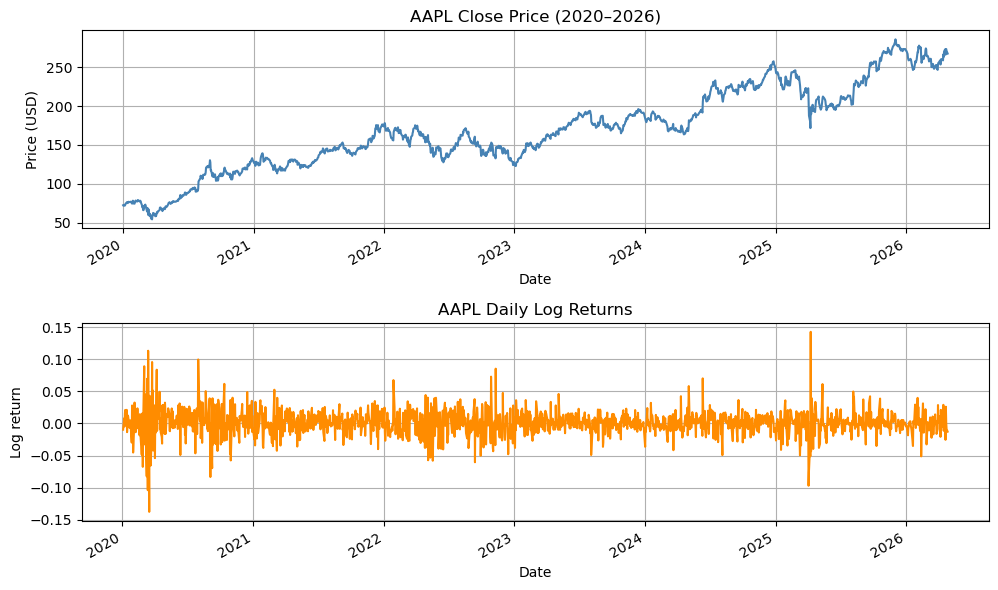

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
prices.plot(ax=axes[0], title="AAPL Close Price (2020–2026)", color="steelblue")
axes[0].set_ylabel("Price (USD)")
log_returns.plot(ax=axes[1], title="AAPL Daily Log Returns", color="darkorange")
axes[1].set_ylabel("Log return")
plt.tight_layout()
plt.show()

## Section 2 — Binomial Tree Setup

### Model parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| $T$ | 0.5 years | Maturity |
| $n$ | 25 | Number of periods |
| $r$ | 1% p.a. | Continuously-compounded risk-free rate |
| $\Delta t = T/n$ | 0.02 years | Step size |
| $u = e^{\sigma\sqrt{\Delta t}}$ | — | CRR up factor |
| $d = e^{-\sigma\sqrt{\Delta t}} = 1/u$ | — | CRR down factor |
| $p$ | 1/2 | Physical probability of an up-move |

### Derivation of the risk-neutral probability $q$ — Task (iv)

Under the risk-neutral measure $Q$, the discounted stock price $e^{-rt}S_t$ is a $Q$-martingale. For one step:
$$S_t = e^{-r\Delta t}\,\mathbb{E}^Q[S_{t+1} \mid \mathcal{F}_t]$$

Substituting the binomial dynamics $S_{t+1} = S_t u$ (prob $q$) or $S_t d$ (prob $1-q$):
$$1 = e^{-r\Delta t}\bigl[qu + (1-q)d\bigr]$$
$$e^{r\Delta t} = qu + (1-q)d = q(u-d) + d$$

Solving for $q$:
$$\boxed{q = \frac{e^{r\Delta t} - d}{u - d}}$$

**No-arbitrage condition:** $0 < q < 1$ requires $d < e^{r\Delta t} < u$, which holds whenever $\sigma\sqrt{\Delta t} > |r\Delta t|$, comfortably satisfied here.

In [4]:
T   = 0.5    # maturity (years)
n   = 25     # number of binomial periods
r   = 0.01   # continuously-compounded risk-free rate (p.a.)
dt  = T / n  # step size

# CRR up/down factors — calibrated so Var[log(S_n/S_0)] = σ²T
u    = np.exp(sigma * np.sqrt(dt))
d    = np.exp(-sigma * np.sqrt(dt))   # = 1/u (recombining tree)

# Risk-neutral probability (derived above)
q    = (np.exp(r * dt) - d) / (u - d)

# Per-step discount factor
disc = np.exp(-r * dt)

# No-arbitrage check: 0 < q < 1
assert 0 < q < 1, f"q = {q:.4f} outside (0,1) — model admits arbitrage!"

print(f"Delta_t  = T/n               = {dt:.6f} years")
print(f"u        = exp(sigma*sqrt(dt)) = {u:.6f}")
print(f"d        = exp(-sigma*sqrt(dt))= {d:.6f}")
print(f"q        = (exp(r*dt)-d)/(u-d) = {q:.6f}")
print(f"disc     = exp(-r*dt)          = {disc:.6f}")
print(f"No-arbitrage check 0 < q < 1  → OK")

Delta_t  = T/n               = 0.020000 years
u        = exp(sigma*sqrt(dt)) = 1.045274
d        = exp(-sigma*sqrt(dt))= 0.956687
q        = (exp(r*dt)-d)/(u-d) = 0.491190
disc     = exp(-r*dt)          = 0.999800
No-arbitrage check 0 < q < 1  → OK


## Section 3 — Path-Dependent Backward Induction — Task (v)

### Why this option is path-dependent

A standard European call has payoff $\max(S_n - K, 0)$. In a recombining CRR tree, $S_n = S_0 u^j d^{n-j}$ depends only on the **count** $j$ of up-moves, not the order — same $(n,j)$ gives same $S_n$ gives same payoff. The tree recombines.

For the floating-strike Asian call:
$$A_T = \max(S_n - \bar{S}_n, 0), \qquad \bar{S}_n = \frac{C_n}{n+1}, \qquad C_n = \sum_{t=0}^n S_t$$

The cumulative sum $C_n$ depends on **every intermediate price**, not just on $j$. Two paths with the same $(n,j)$ — hence the same $S_n$ — can have different $C_n$ if the sequence of ups and downs differs:

> **Same final stock price $\;\not\!\!\!\Rightarrow\;$ same option value.**

#### Concrete $n=2$ example

Take $S_0=100$, $u=1.10$, $d=0.90$. Paths **UD** and **DU** both end at $S_2=99$ ($j=1$):

| Path | $C_2 = S_0+S_1+S_2$ | $\bar{S}_2 = C_2/3$ | Payoff $\max(S_2-\bar{S}_2,0)$ |
|------|---------------------|----------------------|----------------------------------|
| UD (up then down) | $100+110+99=309$ | $103.0$ | $\max(99-103,0)=0$ |
| DU (down then up) | $100+90+99=289$ | $96.\overline{3}$ | $\max(99-96.33,0)=2.67$ |

Same $S_2=99$, different payoffs — the option value at node $(t=2, j=1)$ is **not** a function of the stock price alone.

### Augmented state $(j, C_t)$

We track the pair $(j, C_t)$ at every node. The dynamics are:
$$\text{up:}\quad (j, C_t)\to(j+1,\; C_t + S_t \cdot u)$$
$$\text{down:}\quad (j, C_t)\to(j,\; C_t + S_t \cdot d)$$
making the system Markovian on the augmented state space. The backward-induction recursion is:
$$V_t(j, C) = e^{-r\Delta t}\bigl[q\,V_{t+1}(j+1,\,C+S_t u) + (1-q)\,V_{t+1}(j,\,C+S_t d)\bigr]

In [5]:
def price_floating_asian(S0, sigma, r, T, n):
    """
    Price a European floating-strike Asian call on a recombining binomial tree.

    The state at each node is augmented to (j, C_t) where:
      j   = number of up-moves so far
      C_t = sum of stock prices S_0 + S_1 + ... + S_t   (the running sum)

    We need C_t because the payoff at maturity depends on the average
    of all prices along the path, not just on S_n.
    """
    # --- model parameters for this call ---
    dt   = T / n
    u    = np.exp(sigma * np.sqrt(dt))
    d    = np.exp(-sigma * np.sqrt(dt))
    q    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    # --- FORWARD PASS: enumerate reachable (j, C_t) states  [Tasks (i)+(ii)] ---
    # states[t] is a dict where:
    #     key   = j (number of up-moves at time t)
    #     value = set of all reachable cumulative sums C_t with that j
    states = []
    for t in range(n + 1):
        states.append({})
    states[0][0] = {S0}   # at t=0: 0 up-moves, only C_0 = S_0

    for t in range(n):
        for j in list(states[t].keys()):
            c_set = states[t][j]
            S_now = S0 * (u ** j) * (d ** (t - j))   # Task (i): stock price at node (t,j)
            for C in c_set:
                # up-move: j increases by 1, C grows by S_now * u
                if (j + 1) not in states[t + 1]:
                    states[t + 1][j + 1] = set()
                states[t + 1][j + 1].add(C + S_now * u)
                # down-move: j stays the same, C grows by S_now * d
                if j not in states[t + 1]:
                    states[t + 1][j] = set()
                states[t + 1][j].add(C + S_now * d)

    # --- TERMINAL PAYOFFS  [Task (iii)] ---
    # values[t][j] is a dict mapping C -> option value V(t, j, C)
    values = []
    for t in range(n + 1):
        values.append({})

    for j in states[n]:
        S_T = S0 * (u ** j) * (d ** (n - j))
        values[n][j] = {}
        for C in states[n][j]:
            # floating-strike Asian call payoff: max(S_n - average, 0)
            payoff = S_T - C / (n + 1)
            if payoff < 0:
                payoff = 0.0
            values[n][j][C] = payoff

    # --- BACKWARD INDUCTION  [Task (v)] ---
    # Roll values back from t=n to t=0 using the risk-neutral pricing formula.
    for t in range(n - 1, -1, -1):
        for j in states[t]:
            S_now = S0 * (u ** j) * (d ** (t - j))
            values[t][j] = {}
            for C in states[t][j]:
                V_up = values[t + 1][j + 1][C + S_now * u]
                V_dn = values[t + 1][j    ][C + S_now * d]
                values[t][j][C] = disc * (q * V_up + (1 - q) * V_dn)

    # The unique state at t=0 has j=0 and C_0 = S_0
    return values[0][0][S0]

In [6]:
t0 = time.perf_counter()
price_binomial = price_floating_asian(S0, sigma, r, T, n)
elapsed = time.perf_counter() - t0

print(f"Binomial price at t=0 : {price_binomial:.4f} USD")
print(f"Computation time      : {elapsed:.2f} s")

Binomial price at t=0 : 13.8933 USD
Computation time      : 2.55 s


## Section 4 — Robustness Check — Task (vi)

We re-price the option on a $5\times 5$ grid: $\sigma$ ranges from $80\%$ to $120\%$ of the calibrated value, and $r$ ranges from $0\%$ to $2\%$ p.a. This tests sensitivity to modelling assumptions.

In [7]:
r_grid     = [0.0, 0.005, 0.01, 0.015, 0.02]
sigma_grid = [sigma * 0.8, sigma * 0.9, sigma, sigma * 1.1, sigma * 1.2]

# Empty DataFrame: rows = sigma values, columns = r values
results = pd.DataFrame(
    index=[f"{s:.4f}" for s in sigma_grid],
    columns=[f"{rr:.2%}" for rr in r_grid],
    dtype=float,
)
results.index.name   = "sigma"
results.columns.name = "r"

# Loop over every (sigma, r) pair in the grid and store the price
for s_val in sigma_grid:
    for r_val in r_grid:
        price = price_floating_asian(S0, s_val, r_val, T, n)
        results.loc[f"{s_val:.4f}", f"{r_val:.2%}"] = price

print("Floating-strike Asian call price (USD):")
print(results.round(4).to_string())

Floating-strike Asian call price (USD):
r         0.00%    0.50%    1.00%    1.50%    2.00%
sigma                                              
0.2505  10.8681  11.0271  11.1874  11.3489  11.5118
0.2818  12.2241  12.3818  12.5407  12.7008  12.8619
0.3131  13.5791  13.7357  13.8933  14.0518  14.2114
0.3444  14.9332  15.0886  15.2449  15.4020  15.5601
0.3757  16.2862  16.4404  16.5954  16.7512  16.9078


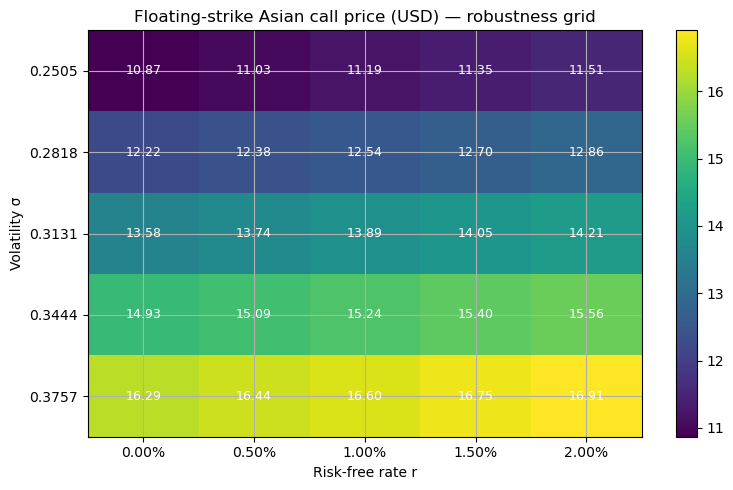

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(results.values.astype(float), cmap="viridis", aspect="auto")
ax.set_xticks(range(len(r_grid)))
ax.set_xticklabels([f"{rr:.2%}" for rr in r_grid])
ax.set_yticks(range(len(sigma_grid)))
ax.set_yticklabels([f"{s:.4f}" for s in sigma_grid])
ax.set_xlabel("Risk-free rate r")
ax.set_ylabel("Volatility σ")
ax.set_title("Floating-strike Asian call price (USD) — robustness grid")
for i in range(len(sigma_grid)):
    for j in range(len(r_grid)):
        ax.text(j, i, f"{results.values[i, j]:.2f}",
                ha="center", va="center", color="white", fontsize=9)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Comments on robustness

- **Monotone in $\sigma$:** The price increases strictly with volatility. Higher $\sigma$ widens the distribution of $S_t$, increasing the expected gap $S_n - \bar{S}_n$ and hence the call value.

- **Mild dependence on $r$:** Both $S_n$ and every term in $\bar{S}_n$ are shifted upward by a higher $r$ (via the $e^{r\Delta t}$ factor in the risk-neutral drift). Since the payoff depends on the *difference* $S_n - \bar{S}_n$, these shifts partially cancel — hence the small positive but limited sensitivity to $r$.

## Section 5 — Monte Carlo Cross-Check (Independent Sanity Check)

Monte Carlo is not required by the assignment, but provides an independent verification of the binomial price by simulating paths directly under the risk-neutral measure $Q$.

### GBM under $Q$
By Itô's lemma applied to $\log S_t$ (where $dS_t = rS_t\,dt + \sigma S_t\,dW_t$ under $Q$):
$$\log S_{t+\Delta t} - \log S_t = \underbrace{\left(r - \tfrac{1}{2}\sigma^2\right)\Delta t}_{\text{Itô-corrected drift}} + \sigma\sqrt{\Delta t}\,Z_t, \quad Z_t\overset{\text{iid}}{\sim}\mathcal{N}(0,1)$$

The $-\tfrac{1}{2}\sigma^2$ correction ensures $\mathbb{E}^Q[S_{t+\Delta t}] = S_t\,e^{r\Delta t}$, consistent with the binomial martingale condition.

The MC estimator is:
$$\hat{V} = e^{-rT}\,\frac{1}{M}\sum_{m=1}^M\max\!\left(S_n^{(m)} - \bar{S}_n^{(m)},\, 0\right)$$

In [9]:
def monte_carlo_floating_asian(S0, sigma, r, T, n, n_sims=200_000, seed=42):
    """Monte Carlo price under GBM risk-neutral measure (independent verification)."""
    rng = np.random.default_rng(seed)
    dt  = T / n

    # (n_sims × n) matrix of standard normals
    Z = rng.standard_normal((n_sims, n))

    # Log-increments under Q with Itô-corrected drift
    log_ret = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

    # Full price paths: shape (n_sims, n+1), includes t=0
    log_paths = np.concatenate(
        [np.full((n_sims, 1), np.log(S0)),
         np.log(S0) + np.cumsum(log_ret, axis=1)],
        axis=1,
    )
    paths = np.exp(log_paths)

    avg    = paths.mean(axis=1)                           # arithmetic average per path
    payoff = np.maximum(paths[:, -1] - avg, 0.0)         # floating-strike payoff
    price  = np.exp(-r * T) * payoff.mean()              # discounted average
    se     = np.exp(-r * T) * payoff.std() / np.sqrt(n_sims)
    return price, se


mc_price, mc_se = monte_carlo_floating_asian(S0, sigma, r, T, n)
ci_lo = mc_price - 1.96 * mc_se
ci_hi = mc_price + 1.96 * mc_se

print(f"Monte Carlo (200k paths) : {mc_price:.4f} USD")
print(f"  95% CI               : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Binomial price         : {price_binomial:.4f} USD")
print(f"Absolute difference    : {abs(mc_price - price_binomial):.4f} USD")

Monte Carlo (200k paths) : 13.9131 USD
  95% CI               : [13.8118, 14.0144]
Binomial price         : 13.8933 USD
Absolute difference    : 0.0199 USD


## Section 6 — Normal Approximation — Task (vii)

We approximate $D_n = S_n - \bar{S}_n$ as normally distributed, then use the truncated normal expectation to compute the option price analytically.

### Key identity: truncated normal expectation

**Claim.** If $X\sim\mathcal{N}(\mu, s^2)$, then:
$$\mathbb{E}[\max(X,0)] = \mu\,\Phi\!\left(\frac{\mu}{s}\right) + s\,\phi\!\left(\frac{\mu}{s}\right)$$

**Derivation.** With density $f(x) = \frac{1}{s}\phi\!\left(\frac{x-\mu}{s}\right)$:
$$\mathbb{E}[\max(X,0)] = \int_0^\infty x\,\frac{1}{s}\phi\!\left(\frac{x-\mu}{s}\right)dx$$

Substitute $z=(x-\mu)/s$, lower limit $z=-\mu/s$:
$$= \int_{-\mu/s}^\infty(\mu+sz)\,\phi(z)\,dz = \mu\underbrace{\int_{-\mu/s}^\infty\phi(z)\,dz}_{=\Phi(\mu/s)} + s\underbrace{\int_{-\mu/s}^\infty z\,\phi(z)\,dz}_{=\phi(\mu/s)}$$

The second integral uses $z\phi(z)=-\phi'(z)$, so $\int_{-\mu/s}^\infty z\phi(z)\,dz = \phi(\mu/s)$.

The option price is therefore:
$$\text{Price}_{\text{normal}} \approx e^{-rT}\bigl[\mu_D\,\Phi(\mu_D/\sigma_D) + \sigma_D\,\phi(\mu_D/\sigma_D)\bigr]$$

> **Simplifying assumption:** $D_n$ is treated as *exactly* normal — it is only approximately so by the CLT. The approximation improves as $n$ grows.

### Moment derivations under $Q$

**Step 1 — One-period gross-return moments.** Let $R_t = S_t/S_{t-1}$; under $Q$ each $R_t$ is i.i.d.:
$$m_1 = \mathbb{E}^Q[R] = qu + (1-q)d = e^{r\Delta t}, \qquad m_2 = \mathbb{E}^Q[R^2] = qu^2 + (1-q)d^2$$

**Step 2 — Marginal price moments.** By independence of returns:
$$\mathbb{E}^Q[S_t] = S_0\,m_1^t, \qquad \mathbb{E}^Q[S_t^2] = S_0^2\,m_2^t$$

**Step 3 — Cross-moment via tower property** ($s\le t$):
$$\mathbb{E}^Q[S_s S_t] = \mathbb{E}^Q\!\left[S_s\,\mathbb{E}^Q[S_t\mid\mathcal{F}_s]\right] = \mathbb{E}^Q\!\left[S_s^2\,m_1^{t-s}\right] = S_0^2\,m_2^s\,m_1^{t-s}$$
By symmetry: $\mathbb{E}^Q[S_s S_t] = S_0^2\,m_2^{\min(s,t)}\,m_1^{|t-s|}$.

**Step 4 — Covariance:**
$$\operatorname{Cov}(S_s, S_t) = S_0^2\!\left(m_2^{\min(s,t)}\,m_1^{|t-s|} - m_1^{s+t}\right)$$

**Step 5 — Mean of $D_n$:**
$$\mu_D = \mathbb{E}^Q[D_n] = \mathbb{E}^Q[S_n] - \frac{1}{n+1}\sum_{t=0}^n\mathbb{E}^Q[S_t] = S_0\,m_1^n - \frac{S_0}{n+1}\sum_{t=0}^n m_1^t$$

**Step 6 — Variance of $D_n$.** Writing $D_n = S_n - \tfrac{1}{n+1}\sum_t S_t$ and applying bilinearity of covariance:
$$\sigma_D^2 = \operatorname{Var}(S_n) - \frac{2}{n+1}\sum_{t=0}^n\operatorname{Cov}(S_n, S_t) + \frac{1}{(n+1)^2}\sum_{s=0}^n\sum_{t=0}^n\operatorname{Cov}(S_s, S_t)$$
The double sum is computed via a vectorised $(n+1)\times(n+1)$ covariance matrix using `np.meshgrid`.

In [10]:
# --- One-period gross-return moments under Q ---
m1 = np.exp(r * dt)                  # E^Q[R]   = e^{r*dt}
m2 = q * u**2 + (1 - q) * d**2       # E^Q[R^2] = q*u^2 + (1-q)*d^2

# --- Marginal price moments E[S_t] for t = 0..n ---
ES = np.zeros(n + 1)
for t in range(n + 1):
    ES[t] = S0 * m1**t

# --- Build the (n+1) x (n+1) covariance matrix Cov(S_s, S_t) ---
# We use the formula  E[S_s * S_t] = S0^2 * m2^min(s,t) * m1^|s-t|
# and then  Cov(S_s, S_t) = E[S_s * S_t] - E[S_s] * E[S_t].
cov_mat = np.zeros((n + 1, n + 1))
for s in range(n + 1):
    for t in range(n + 1):
        E_SsSt        = S0**2 * m2**min(s, t) * m1**abs(s - t)
        cov_mat[s, t] = E_SsSt - ES[s] * ES[t]

# --- Mean of D_n  =  E[S_n] - (1/(n+1)) * sum_t E[S_t] ---
sum_ES = 0.0
for t in range(n + 1):
    sum_ES += ES[t]
E_Dn = ES[n] - sum_ES / (n + 1)

# --- Variance of D_n via bilinearity of Cov ---
# sigma_D^2 = Var(S_n) - 2/(n+1) * sum_t Cov(S_n, S_t)
#                       + 1/(n+1)^2 * sum_s sum_t Cov(S_s, S_t)
Var_Sn = cov_mat[n, n]

cov_Sn_sum = 0.0
for t in range(n + 1):
    cov_Sn_sum += cov_mat[n, t]

cov_total = 0.0
for s in range(n + 1):
    for t in range(n + 1):
        cov_total += cov_mat[s, t]

Var_Dn = Var_Sn - 2/(n+1) * cov_Sn_sum + cov_total / (n + 1)**2
sd_Dn  = np.sqrt(Var_Dn)

# --- Closed-form normal-approximation price using the truncated normal identity ---
# E[max(X, 0)] = mu * Phi(mu/s) + s * phi(mu/s)   for X ~ N(mu, s^2)
ratio        = E_Dn / sd_Dn
price_normal = np.exp(-r * T) * (E_Dn * norm.cdf(ratio) + sd_Dn * norm.pdf(ratio))

print(f"m_1                        = {m1:.6f}")
print(f"m_2                        = {m2:.6f}")
print(f"mu_D  (E[D_n])             = {E_Dn:.4f} USD")
print(f"sd_D  (sqrt(Var[D_n]))     = {sd_Dn:.4f} USD")
print()
print(f"Normal-approximation price = {price_normal:.4f} USD")
print(f"Binomial price             = {price_binomial:.4f} USD")
print(f"Absolute difference        = {price_normal - price_binomial:+.4f} USD")
print(f"Relative difference        = {(price_normal - price_binomial)/price_binomial:+.2%}")

m_1                        = 1.000200
m_2                        = 1.002361
mu_D  (E[D_n])             = 0.6712 USD
sd_D  (sqrt(Var[D_n]))     = 34.6769 USD

Normal-approximation price = 14.1016 USD
Binomial price             = 13.8933 USD
Absolute difference        = +0.2083 USD
Relative difference        = +1.50%


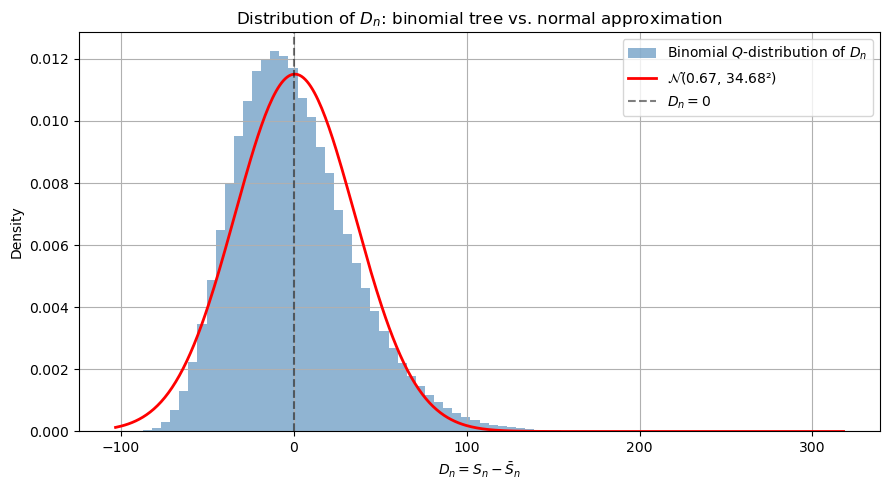

In [11]:
# Forward pass tracking the Q-probability of every reachable (j, C_t) state.
# prob_states[t][j] is a dict mapping C -> Q-probability of that state.
prob_states = []
for t in range(n + 1):
    prob_states.append({})
prob_states[0][0] = {S0: 1.0}

for t in range(n):
    for j in list(prob_states[t].keys()):
        c_dict = prob_states[t][j]
        S_now  = S0 * (u**j) * (d**(t - j))
        for C in c_dict:
            prob = c_dict[C]
            # up-move
            if (j + 1) not in prob_states[t + 1]:
                prob_states[t + 1][j + 1] = {}
            new_C_up = C + S_now * u
            if new_C_up in prob_states[t + 1][j + 1]:
                prob_states[t + 1][j + 1][new_C_up] += prob * q
            else:
                prob_states[t + 1][j + 1][new_C_up] = prob * q
            # down-move
            if j not in prob_states[t + 1]:
                prob_states[t + 1][j] = {}
            new_C_dn = C + S_now * d
            if new_C_dn in prob_states[t + 1][j]:
                prob_states[t + 1][j][new_C_dn] += prob * (1 - q)
            else:
                prob_states[t + 1][j][new_C_dn] = prob * (1 - q)

# Collect all terminal D_n values together with their Q-probabilities
Dn_values = []
Dn_probs  = []
for j in prob_states[n]:
    S_T = S0 * (u**j) * (d**(n - j))
    for C in prob_states[n][j]:
        Dn_values.append(S_T - C / (n + 1))
        Dn_probs.append(prob_states[n][j][C])
Dn_values = np.array(Dn_values)
Dn_probs  = np.array(Dn_probs)

# Sanity check: Q-probabilities must sum to 1
assert abs(Dn_probs.sum() - 1.0) < 1e-9, "Q-probabilities must sum to 1"

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(Dn_values, bins=80, weights=Dn_probs, density=True,
        alpha=0.6, color="steelblue", label=r"Binomial $Q$-distribution of $D_n$")
xx = np.linspace(Dn_values.min(), Dn_values.max(), 400)
ax.plot(xx, norm.pdf(xx, loc=E_Dn, scale=sd_Dn), "r-", lw=2,
        label=r"$\mathcal{N}$" + f"({E_Dn:.2f}, {sd_Dn:.2f}²)")
ax.axvline(0, color="k", linestyle="--", alpha=0.5, label=r"$D_n = 0$")
ax.set_xlabel(r"$D_n = S_n - \bar{S}_n$")
ax.set_ylabel("Density")
ax.set_title(r"Distribution of $D_n$: binomial tree vs. normal approximation")
ax.legend()
plt.tight_layout()
plt.show()

## Section 7 — Summary of Results

In [12]:
print("=" * 60)
print("SUMMARY OF RESULTS")
print("=" * 60)
print(f"  Data source          : apple stock data.xlsx (official)")
print(f"  S_0 (2026-04-27)     : {S0:.2f} USD")
print(f"  sigma (annualised)   : {sigma:.4f}")
print(f"  T = {T}  n = {n}  r = {r:.1%}")
print("  " + "-"*56)
print(f"  Binomial price (exact)    = {price_binomial:.4f} USD")
print(f"  Monte Carlo  (200k paths) = {mc_price:.4f} USD  (±{1.96*mc_se:.4f})")
print(f"  Normal approximation      = {price_normal:.4f} USD")
print(f"  Relative diff (norm vs bin) = {(price_normal-price_binomial)/price_binomial:+.2%}")
print("=" * 60)

SUMMARY OF RESULTS
  Data source          : apple stock data.xlsx (official)
  S_0 (2026-04-27)     : 267.61 USD
  sigma (annualised)   : 0.3131
  T = 0.5  n = 25  r = 1.0%
  --------------------------------------------------------
  Binomial price (exact)    = 13.8933 USD
  Monte Carlo  (200k paths) = 13.9131 USD  (±0.1013)
  Normal approximation      = 14.1016 USD
  Relative diff (norm vs bin) = +1.50%
